In [2]:
import pandas as pd
from configs.dataset_config import DATA_DATE_SUFFIX

version = DATA_DATE_SUFFIX

In [4]:
df = pd.read_parquet(f'../datasets/{version}/inference_flagged_listings_{version}.parquet')
df

,property_listing_id,is_realistic,reason,location_id,location_lvl_0_id,location_lvl_0_name,location_lvl_1_id,location_lvl_1_name,location_lvl_2_id,location_lvl_2_name,...,price_outlier_type,price_deviation_ratio,is_sqft_outlier,sqft_outlier_type,sqft_deviation_ratio,is_any_outlier,pts_normalized_score,price_normalized_score,sqft_normalized_score,outlier_rank
0,0016FGA5TSZTPH80AQYJF23HV8,None,None,1587,4,Sharjah,184,Sharjah Industrial Area,1587,Industrial Area 18,...,not_outlier,0.779219,False,not_outlier,0.981132,False,-0.041346,-0.044156,-0.003774,NaN
1,0049YM8SMW4KA99VFCGZFZG06R,None,None,15812,1,Dubai,129,DAMAC Hills,15812,Damac District,...,not_outlier,1.151124,False,not_outlier,0.834190,False,0.083298,0.050375,-0.055270,NaN
2,00EEAG55JKR1AY61JVJTA4PKNM,None,None,8451,1,Dubai,36,Business Bay,8450,Al Habtoor City,...,not_outlier,1.000000,False,not_outlier,1.115826,False,-0.012835,0.000000,0.038609,NaN
3,00FRSPF36R5J3E8JF09EXN1MRC,None,None,10959,5,Ajman,10537,Al Zahya,10959,Al Zaheya Gardens,...,not_outlier,1.000000,False,not_outlier,0.753500,False,0.163570,0.000000,-0.123250,NaN
4,01JP8XE4HR7NNB572VB2W3AJGQ,None,None,4409,1,Dubai,88,Sheikh Zayed Road,4409,Aspin Tower,...,not_outlier,0.948276,False,not_outlier,0.860000,False,-0.015646,-0.010345,-0.028000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
362391,ZZBCEBBJMM5NX3AR5MQDXVC7F8,None,None,13513,1,Dubai,73,Jumeirah Village Circle,1015,District 18,...,not_outlier,0.858638,False,not_outlier,0.952505,False,-0.029929,-0.047121,-0.015832,NaN
362392,ZZJ7B9EKD61DGSVK8N1DB8ETCW,None,None,12886,1,Dubai,131,Town Square,12886,The Hamilton,...,not_outlier,0.833333,False,not_outlier,1.295522,False,-0.117157,-0.083333,0.147761,NaN
362393,ZZK80Q1BMXC98FD9ND8XJXG3JG,None,None,13233,1,Dubai,73,Jumeirah Village Circle,1014,District 14,...,not_outlier,1.465116,False,not_outlier,1.718131,False,-0.052832,0.232558,0.359065,NaN
362394,ZZRE483A417K23PQJQZSGPTAV8,None,None,15931,1,Dubai,88,Sheikh Zayed Road,15931,Sol Luxe,...,not_outlier,1.026316,False,not_outlier,0.955414,False,0.013425,0.008772,-0.014862,NaN


In [5]:
df.columns

Index(['property_listing_id', 'is_realistic', 'reason', 'location_id',
       'location_lvl_0_id', 'location_lvl_0_name', 'location_lvl_1_id',
       'location_lvl_1_name', 'location_lvl_2_id', 'location_lvl_2_name',
       'location_lvl_3_id', 'location_lvl_3_name', 'location_lvl_4_id',
       'location_lvl_4_name', 'location_lvl_5_id', 'location_lvl_5_name',
       'location_lvl_6_id', 'location_lvl_6_name', 'location_lvl_7_id',
       'location_lvl_7_name', 'offering_type_id', 'housing_type_id',
       'property_sqft', 'property_furnished', 'property_floor',
       'property_cheques', 'property_parking', 'property_listing_level',
       'start_time', 'start_year', 'start_month', 'end_time', 'end_year',
       'end_month', 'dtcm_permit', 'complaince_type', 'bedrooms', 'bathrooms',
       'completion_status', 'yearly_price', 'property_permit_number',
       'listing_short_term_flag', 'client_id', 'salesforce_account_no',
       'price', 'property_price_type_id', 'offering_type_name',


In [14]:
df['price_lb'] = df['price_median'] * (1.0/df['price_multiplier'])
df['price_ub'] = df['price_median'] * df['price_multiplier']

df['size_lb'] = df['property_sqft_median'] * (1.0/df['sqft_multiplier'])
df['size_ub'] = df['property_sqft_median'] * df['sqft_multiplier']

df['pts_lb'] = df['price_to_sqft_median'] * (1.0/df['pts_multiplier'])
df['pts_ub'] = df['price_to_sqft_median'] * df['pts_multiplier']

df['is_price_outlier_2'] = (df['price'] < df['price_lb']) | (df['price'] > df['price_ub'])

df['is_size_outlier_2'] = (df['property_sqft'] < df['size_lb']) | (df['property_sqft'] > df['size_ub'])

df['is_pts_outlier_2'] = (df['price_to_sqft'] < df['pts_lb']) | (df['price_to_sqft'] > df['pts_ub'])


In [15]:
print((df['is_price_outlier'] != df['is_price_outlier_2']).sum())
print((df['is_sqft_outlier'] != df['is_size_outlier_2']).sum())
print((df['is_pts_outlier'] != df['is_pts_outlier_2']).sum())

0
0
0


In [18]:
df['is_pts_outlier_2'].sum(), df['is_price_outlier_2'].sum(), df['is_size_outlier_2'].sum()

(np.int64(2139), np.int64(2240), np.int64(3099))

In [19]:
cols = ['property_listing_id', 'segment_key',
        'price','price_lb', 'price_ub',
        'property_sqft', 'size_lb', 'size_ub',
        'price_to_sqft', 'pts_lb', 'pts_ub'
        ]
buffer_df = df[cols].copy()
buffer_df

,property_listing_id,segment_key,price,price_lb,price_ub,property_sqft,size_lb,size_ub,price_to_sqft,pts_lb,pts_ub
0,0016FGA5TSZTPH80AQYJF23HV8,1587|Show Room|Commercial Rent|Yearly,150000.0,3.208342e+04,1155003.0,2600.0,441.666667,15900.0,57.692308,12.121212,436.363636
1,0049YM8SMW4KA99VFCGZFZG06R,15812|Apartment|Residential Sale|Sale|1 Bed,1406673.0,3.055000e+05,4888000.0,649.0,194.500000,3112.0,2167.446841,433.526012,6936.416185
2,00EEAG55JKR1AY61JVJTA4PKNM,8451|Apartment|Residential Rent|Yearly|1 Bed,120000.0,3.000000e+04,480000.0,973.0,218.000000,3488.0,123.329908,32.067248,513.075965
3,00FRSPF36R5J3E8JF09EXN1MRC,10959|Villa|Residential Rent|Monthly|6 Bed,20000.0,6.666667e+03,60000.0,3014.0,1333.333333,12000.0,6.635700,1.666667,15.000000
4,01JP8XE4HR7NNB572VB2W3AJGQ,4409|Business Centre|Commercial Rent|Yearly,55000.0,9.666667e+03,348000.0,215.0,41.666667,1500.0,255.813953,46.254209,1665.151515
...,...,...,...,...,...,...,...,...,...,...,...
362391,ZZBCEBBJMM5NX3AR5MQDXVC7F8,13513|Apartment|Residential Sale|Sale|1 Bed,1008900.0,2.937500e+05,4700000.0,732.0,192.125000,3074.0,1378.278689,378.559923,6056.958768
362392,ZZJ7B9EKD61DGSVK8N1DB8ETCW,12886|Apartment|Residential Rent|Yearly|Studio,50000.0,2.000000e+04,180000.0,434.0,111.666667,1005.0,115.207373,50.154321,451.388889
362393,ZZK80Q1BMXC98FD9ND8XJXG3JG,13233|Villa|Residential Sale|Sale|4 Bed,6300000.0,1.433333e+06,12900000.0,3511.0,681.166667,6130.5,1794.360581,668.787252,6019.085264
362394,ZZRE483A417K23PQJQZSGPTAV8,15931|Apartment|Residential Sale|Sale|2 Bed,4095000.0,9.975000e+05,15960000.0,1200.0,314.000000,5024.0,3412.500000,820.095314,13121.525020


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

buffer_percentages = np.arange(-10, 11, 1)

results = []

for buffer_pct in buffer_percentages:
    buffer_multiplier_lower = 1 - (buffer_pct / 100)
    buffer_multiplier_upper = 1 + (buffer_pct / 100)

    price_lb_lower = buffer_df['price_lb'] * buffer_multiplier_lower
    price_ub_lower = buffer_df['price_ub'].copy()
    price_outside_lower = ((buffer_df['price'] < price_lb_lower) |
                           (buffer_df['price'] > price_ub_lower)).sum()
    pct_outside_price_lower = (price_outside_lower / len(buffer_df)) * 100

    price_lb_upper = buffer_df['price_lb'].copy()
    price_ub_upper = buffer_df['price_ub'] * buffer_multiplier_upper
    price_outside_upper = ((buffer_df['price'] < price_lb_upper) |
                           (buffer_df['price'] > price_ub_upper)).sum()
    pct_outside_price_upper = (price_outside_upper / len(buffer_df)) * 100

    price_lb_both = buffer_df['price_lb'] * buffer_multiplier_lower
    price_ub_both = buffer_df['price_ub'] * buffer_multiplier_upper
    price_outside_both = ((buffer_df['price'] < price_lb_both) |
                          (buffer_df['price'] > price_ub_both)).sum()
    pct_outside_price_both = (price_outside_both / len(buffer_df)) * 100

    size_lb_lower = buffer_df['size_lb'] * buffer_multiplier_lower
    size_ub_lower = buffer_df['size_ub'].copy()
    size_outside_lower = ((buffer_df['property_sqft'] < size_lb_lower) |
                          (buffer_df['property_sqft'] > size_ub_lower)).sum()
    pct_outside_size_lower = (size_outside_lower / len(buffer_df)) * 100

    size_lb_upper = buffer_df['size_lb'].copy()
    size_ub_upper = buffer_df['size_ub'] * buffer_multiplier_upper
    size_outside_upper = ((buffer_df['property_sqft'] < size_lb_upper) |
                          (buffer_df['property_sqft'] > size_ub_upper)).sum()
    pct_outside_size_upper = (size_outside_upper / len(buffer_df)) * 100

    size_lb_both = buffer_df['size_lb'] * buffer_multiplier_lower
    size_ub_both = buffer_df['size_ub'] * buffer_multiplier_upper
    size_outside_both = ((buffer_df['property_sqft'] < size_lb_both) |
                         (buffer_df['property_sqft'] > size_ub_both)).sum()
    pct_outside_size_both = (size_outside_both / len(buffer_df)) * 100

    pts_lb_lower = buffer_df['pts_lb'] * buffer_multiplier_lower
    pts_ub_lower = buffer_df['pts_ub'].copy()
    pts_outside_lower = ((buffer_df['price_to_sqft'] < pts_lb_lower) |
                         (buffer_df['price_to_sqft'] > pts_ub_lower)).sum()
    pct_outside_pts_lower = (pts_outside_lower / len(buffer_df)) * 100

    pts_lb_upper = buffer_df['pts_lb'].copy()
    pts_ub_upper = buffer_df['pts_ub'] * buffer_multiplier_upper
    pts_outside_upper = ((buffer_df['price_to_sqft'] < pts_lb_upper) |
                         (buffer_df['price_to_sqft'] > pts_ub_upper)).sum()
    pct_outside_pts_upper = (pts_outside_upper / len(buffer_df)) * 100

    pts_lb_both = buffer_df['pts_lb'] * buffer_multiplier_lower
    pts_ub_both = buffer_df['pts_ub'] * buffer_multiplier_upper
    pts_outside_both = ((buffer_df['price_to_sqft'] < pts_lb_both) |
                        (buffer_df['price_to_sqft'] > pts_ub_both)).sum()
    pct_outside_pts_both = (pts_outside_both / len(buffer_df)) * 100

    results.append({
        'buffer_pct': buffer_pct,
        'price_lower_only': pct_outside_price_lower,
        'price_upper_only': pct_outside_price_upper,
        'price_both': pct_outside_price_both,
        'size_lower_only': pct_outside_size_lower,
        'size_upper_only': pct_outside_size_upper,
        'size_both': pct_outside_size_both,
        'pts_lower_only': pct_outside_pts_lower,
        'pts_upper_only': pct_outside_pts_upper,
        'pts_both': pct_outside_pts_both
    })

results_df = pd.DataFrame(results)
results_df


,buffer_pct,price_lower_only,price_upper_only,price_both,size_lower_only,size_upper_only,size_both,pts_lower_only,pts_upper_only,pts_both
0,-10,0.660051,0.702270,0.744214,0.889359,0.948410,0.982627,0.623075,0.616453,0.649290
1,-9,0.656464,0.691509,0.729865,0.885771,0.930474,0.961103,0.620040,0.612038,0.641839
2,-8,0.654533,0.687370,0.723794,0.881356,0.922472,0.948686,0.617005,0.609554,0.636320
3,-7,0.652325,0.676332,0.710549,0.878597,0.912814,0.936269,0.611762,0.605691,0.627214
4,-6,0.649290,0.668054,0.699235,0.875286,0.905087,0.925231,0.608174,0.601828,0.619764
5,-5,0.639632,0.658396,0.679919,0.872802,0.901224,0.918884,0.603208,0.600448,0.613417
6,-4,0.636596,0.647910,0.666398,0.870595,0.891566,0.907019,0.601000,0.599068,0.609830
7,-3,0.634665,0.636872,0.653429,0.865628,0.881632,0.892118,0.598241,0.597689,0.605691
8,-2,0.631078,0.632457,0.645427,0.863972,0.875562,0.884392,0.596033,0.595205,0.601000
9,-1,0.628318,0.624731,0.634941,0.859557,0.865076,0.869491,0.593826,0.593826,0.597413


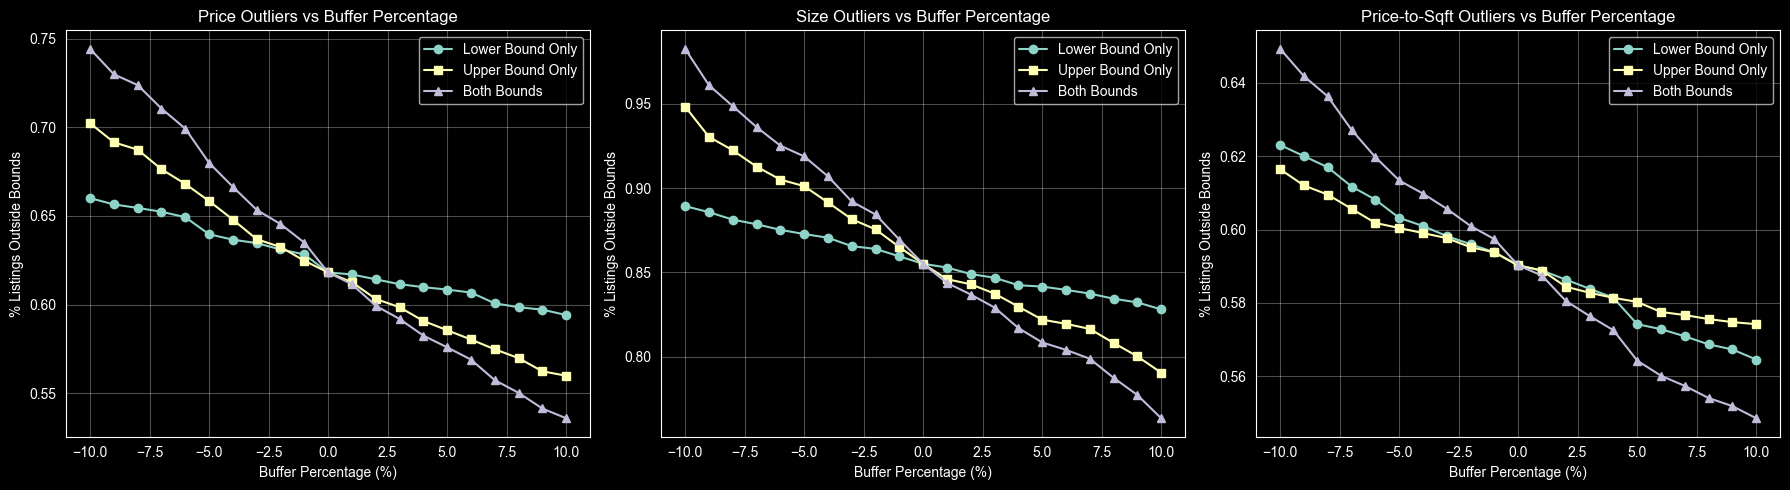

In [33]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(results_df['buffer_pct'], results_df['price_lower_only'],
             marker='o', label='Lower Bound Only')
axes[0].plot(results_df['buffer_pct'], results_df['price_upper_only'],
             marker='s', label='Upper Bound Only')
axes[0].plot(results_df['buffer_pct'], results_df['price_both'],
             marker='^', label='Both Bounds')
axes[0].set_xlabel('Buffer Percentage (%)')
axes[0].set_ylabel('% Listings Outside Bounds')
axes[0].set_title('Price Outliers vs Buffer Percentage')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(results_df['buffer_pct'], results_df['size_lower_only'],
             marker='o', label='Lower Bound Only')
axes[1].plot(results_df['buffer_pct'], results_df['size_upper_only'],
             marker='s', label='Upper Bound Only')
axes[1].plot(results_df['buffer_pct'], results_df['size_both'],
             marker='^', label='Both Bounds')
axes[1].set_xlabel('Buffer Percentage (%)')
axes[1].set_ylabel('% Listings Outside Bounds')
axes[1].set_title('Size Outliers vs Buffer Percentage')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(results_df['buffer_pct'], results_df['pts_lower_only'],
             marker='o', label='Lower Bound Only')
axes[2].plot(results_df['buffer_pct'], results_df['pts_upper_only'],
             marker='s', label='Upper Bound Only')
axes[2].plot(results_df['buffer_pct'], results_df['pts_both'],
             marker='^', label='Both Bounds')
axes[2].set_xlabel('Buffer Percentage (%)')
axes[2].set_ylabel('% Listings Outside Bounds')
axes[2].set_title('Price-to-Sqft Outliers vs Buffer Percentage')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [34]:
import matplotlib.pyplot as plt

def plot_buffer_analysis(results_df, buffer_range=(0, 10), metric_type='pts'):
    """
    Plot buffer analysis for a specific metric type and buffer range.

    Parameters:
    -----------
    results_df : pd.DataFrame
        DataFrame containing buffer analysis results
    buffer_range : tuple, default (0, 10)
        Range of buffer percentages to plot (min, max)
    metric_type : str, default 'pts'
        Type of metric to plot. Options: 'pts', 'price', 'size'
    """
    filtered_df = results_df[
        (results_df['buffer_pct'] >= buffer_range[0]) &
        (results_df['buffer_pct'] <= buffer_range[1])
    ]

    type_mapping = {
        'pts': 'Price-to-Sqft',
        'price': 'Price',
        'size': 'Size'
    }

    title = type_mapping.get(metric_type, metric_type.capitalize())

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(filtered_df['buffer_pct'], filtered_df[f'{metric_type}_lower_only'],
            marker='o', label='Lower Bound Only', linewidth=2)
    ax.plot(filtered_df['buffer_pct'], filtered_df[f'{metric_type}_upper_only'],
            marker='s', label='Upper Bound Only', linewidth=2)
    ax.plot(filtered_df['buffer_pct'], filtered_df[f'{metric_type}_both'],
            marker='^', label='Both Bounds', linewidth=2)

    ax.set_xlabel('Buffer Percentage (%)', fontsize=12)
    ax.set_ylabel('% Listings Outside Bounds', fontsize=12)
    ax.set_title(f'{title} Outliers vs Buffer Percentage', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


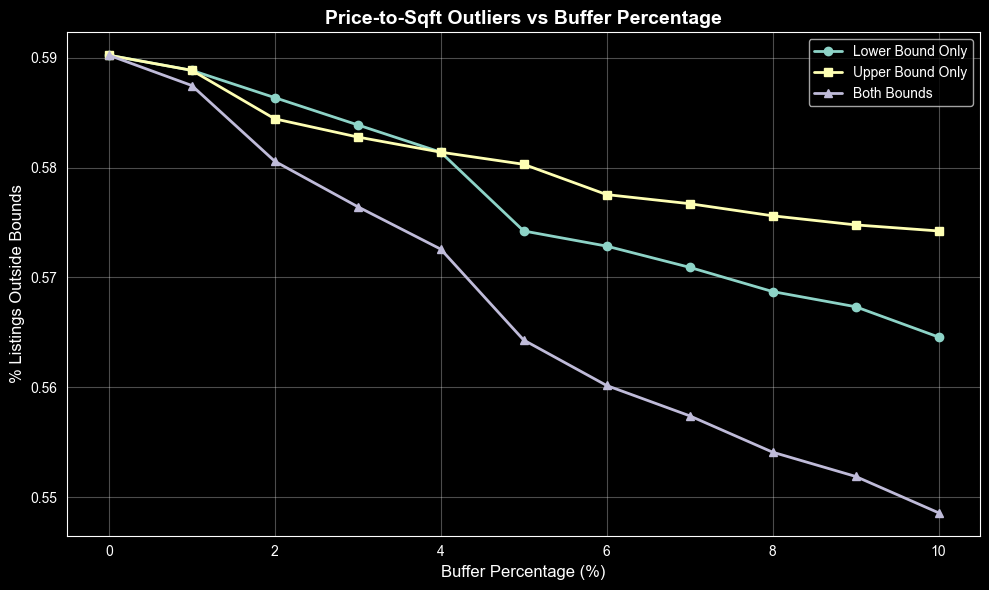

In [35]:
plot_buffer_analysis(results_df, buffer_range=(0, 10), metric_type='pts')


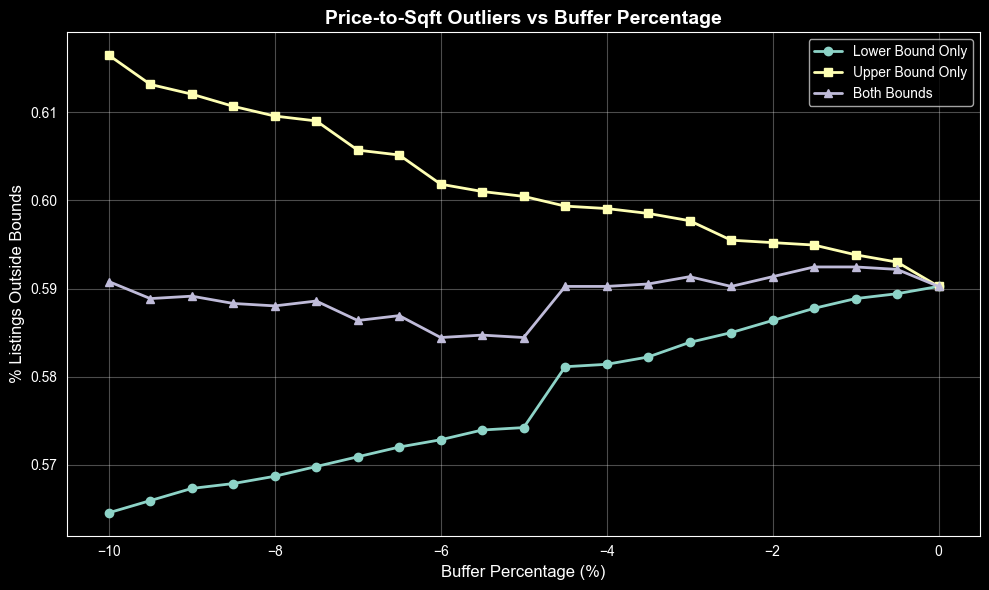

In [30]:
plot_buffer_analysis(results_df, buffer_range=(-10, 0), metric_type='pts') # inwards


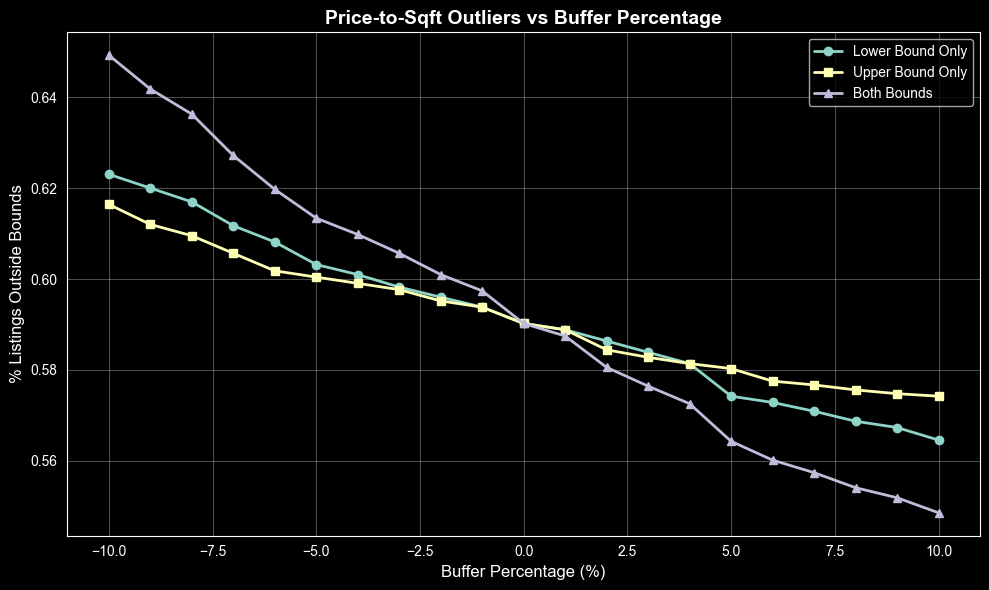

In [36]:
plot_buffer_analysis(results_df, buffer_range=(-10, 10), metric_type='pts')
